# Conjunctions with Inequality Propositions

This notebook studies the efficient implementation of support (coverage) and, crucially, implication checks for inequality propositions about ordinal variables. 

With naive binarisation, checking the implications of a conjunction with support count $m$ costs $\Theta(mr)$ where $r$ is the number of propositions not included in the conjunction. For $d$ ordinal variables, $r$ can be up to $dn$, leading for conjunctions with large support count to a cost of $\Theta(dn^2)$. Our goal is to reduce this to $\Theta(dn)$ by directly operating on the underlying numerical data matrix. 


## Example Data

We will start the investigation this with the following small random dataset of three variables and five data points.

In [1]:
import numpy as np

RNG = np.random.default_rng(seed=0)
x = RNG.multivariate_normal([0, 0, 0], [[1, 0.5, 0],[0.5, 1, 0], [0, 0, 1]], size=5)
x


array([[-0.42909689,  0.21132576, -0.13210486],
       [-0.27164369,  0.08995136, -0.53566937],
       [-0.77742955, -1.48116478,  0.94708096],
       [ 1.07522415,  1.11655013, -0.62327446],
       [ 2.63649119,  1.39058024, -0.21879166]])

Text(0, 0.5, '$x_2$')

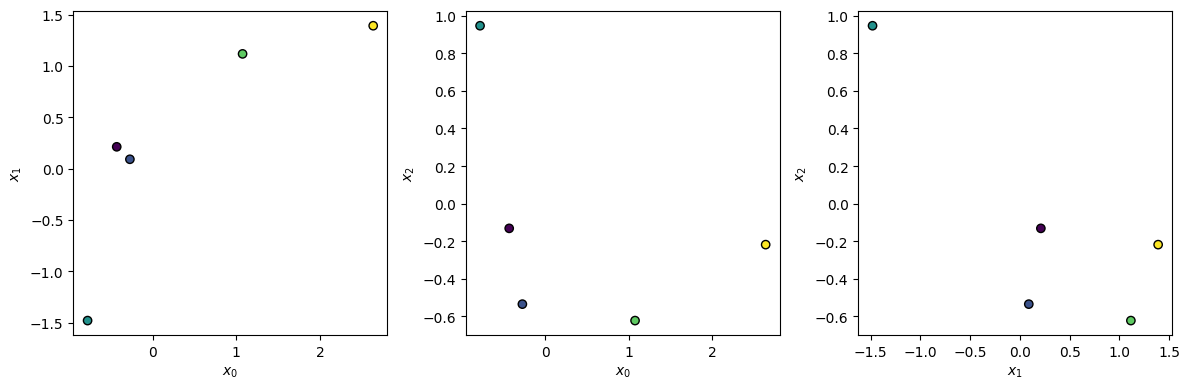

In [2]:
from matplotlib import pyplot as plt

_, axs = plt.subplots(1, 3, figsize=(12, 4), tight_layout=False)
axs[0].scatter(x[:, 0], x[:, 1], c=np.arange(5), ec='black')
axs[0].set_xlabel('$x_0$')
axs[0].set_ylabel('$x_1$')
axs[1].scatter(x[:, 0], x[:, 2], c=np.arange(5), ec='black')
axs[1].set_xlabel('$x_0$')
axs[1].set_ylabel('$x_2$')
axs[2].scatter(x[:, 1], x[:, 2], c=np.arange(5), ec='black')
axs[2].set_xlabel('$x_1$')
axs[2].set_ylabel('$x_2$')

## Proposition Representation

We generically represent propositons as $sx_j \geq t$ where $s \in \{-1, 1\}$. This way, $x_j \leq t$ is represented as $-x_j \geq -t$. This means that a whole proposition store with $k$ propositions can be represented by $k$-vectors $\boldsymbol{v} \in \{0,\dots, p\}^k$, $\boldsymbol{t} \in \mathbb{R}^k$, and $\boldsymbol{s} \in \{-1, 1\}$. This approach has to be refined to also represent propositions for categorical attributes, as for those there should only be inequality or subset propositions.

The following function creates propositions for variable $j$ all $t \in \{x_{1,j}, \dots, x_{n,j}\}$. This creates empirically trivial propositions for the maximum and minimum values, which should be avoided in a real implementation.

In [3]:
def propositions(x):
    n, p = x.shape
    v = np.repeat(np.arange(p), n)
    t = x.T.flatten()
    s = np.repeat([1, -1], p*n)
    return np.concatenate((v, v)), np.concatenate((t, -t)), s


v, t, s = propositions(x)
v, t, s

(array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1,
        1, 1, 1, 2, 2, 2, 2, 2]),
 array([-0.42909689, -0.27164369, -0.77742955,  1.07522415,  2.63649119,
         0.21132576,  0.08995136, -1.48116478,  1.11655013,  1.39058024,
        -0.13210486, -0.53566937,  0.94708096, -0.62327446, -0.21879166,
         0.42909689,  0.27164369,  0.77742955, -1.07522415, -2.63649119,
        -0.21132576, -0.08995136,  1.48116478, -1.11655013, -1.39058024,
         0.13210486,  0.53566937, -0.94708096,  0.62327446,  0.21879166]),
 array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]))

The following materialises an explicit boolean matrix representation of the propositions for the given data. This is for illustrative purposes only and precisely what we want to avoid for an efficient implementation.

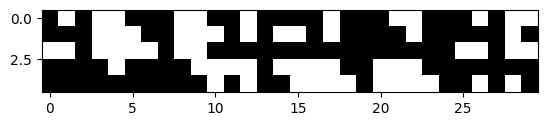

In [4]:
p = s*x[:, v] >= t
plt.imshow(p, cmap='Greys', interpolation='none')
plt.show()

In [5]:
np.where(p.sum(axis=0)==len(x))

(array([ 2,  7, 13, 19, 24, 27]),)

In [6]:
def prop_to_string(v, t, s):
    return f'x{v+1} {'>=' if s==1 else '<='} {s*t:.3g}'
    
prop_to_string(v[0], t[0], s[0]), prop_to_string(v[11], t[11], s[11]), prop_to_string(v[20], t[20], s[20])

('x1 >= -0.429', 'x3 >= -0.536', 'x2 <= 0.211')

In [7]:
p[:, 0], p[:, 11], p[:, 20]

(array([ True,  True, False,  True,  True]),
 array([ True,  True,  True, False,  True]),
 array([ True,  True,  True, False, False]))

In [8]:
def support(p, x, v, t, s, sup=None):
    sup = sup if sup is not None else np.arange(len(x))
    return sup[s[p]*x[sup, v[p]] >= t[p]]

support(0, x, v, t, s)

array([0, 1, 3, 4])

In [9]:
# x[np.ix_([0, 1, 2], [0, 2])]

In [10]:
def extended_support(q, x, v, t, s, sup=None):
    sup = sup if sup is not None else np.arange(len(x))
    q = np.atleast_1d(q)
    return sup[np.prod(s[q]*x[np.ix_(sup, v[q])] >= t[q], axis=1, dtype=bool)]

extended_support(np.array([0, 11]), x, v, t, s)

array([0, 1, 4])

In [11]:
def implications(x, v, t, s, sup):
    l=np.min(x[sup], axis=0)
    u=np.max(x[sup], axis=0)
    
    res = np.zeros(len(v), dtype=bool)
    np.greater_equal(l[v], t, where=s==1, out=res)
    np.greater_equal(-u[v], t, where=s==-1, out=res)
    
    return np.flatnonzero(res)

sup = extended_support(np.array([0, 11]), x, v, t, s)
imps = implications(x, v, t, s, sup)
crit = np.argmax(imps) if np.any(imps) else -1
crit, imps

(np.int64(9), array([ 0,  2,  6,  7, 11, 13, 19, 24, 25, 27]))

In [12]:
sup = np.arange(len(x))
l=np.min(x[sup], axis=0)
u=np.max(x[sup], axis=0)
print(l, u)
print(np.max(x, axis=0))

np.where(implications(x, v, t, s, sup))

[-0.77742955 -1.48116478 -0.62327446] [2.63649119 1.39058024 0.94708096]
[2.63649119 1.39058024 0.94708096]


(array([0, 1, 2, 3, 4, 5]),)

In [13]:
print(x.dtype)

float64


In [14]:
from numba.types import int64, float64
from numba.experimental import jitclass

@jitclass
class Propositionalization:

    v: int64[:]
    t: float64[:]
    s: int64[:]

    def __init__(self, v, t, s):
        self.v = v
        self.t = t
        self.s = s

    def test(self, q, x):
        return self.s[q][:, None]*x[self.v[q]]

    def support(self, q: int64[:], x: float64[:,:]):
        # q = np.atleast_1d(q)
        return np.prod(s[q]*x[v[q]] >= t[q], axis=1, dtype=bool)

    def to_string(self, j):
        return f'x{v[j]+1} {'>=' if s[j]==1 else '<='} {s[j]*t[j]}'

def make_propositionalization(x):
    n, p = x.shape
    v = np.repeat(np.arange(p), n)
    t = x.T.flatten()
    s = np.repeat([1, -1], p*n)
    return Propositionalization(np.concatenate((v, v)), np.concatenate((t, -t)), s)

props = make_propositionalization(x)
props.test(np.array([0, 11]), x)

array([[-0.42909689,  0.21132576, -0.13210486],
       [-0.77742955, -1.48116478,  0.94708096]])

In [15]:
str(props.s[0]*props.t[0])

'-0.4290968907119538'

In [16]:
from numba.types import int64
from numba.experimental import jitclass

@jitclass
class Node:

    key: int64[:]
    closure: int64[:]

    def __init__(self, key, closure, support):
        self.key = key
        self.closure = closure
        self.support = support


# class TreeSearch:

#     queue: 

#     def __init__(self):


Node(np.array([0]))

TypeError: missing a required argument: 'closure'